Paquetes necesarios

In [2]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

Inicializaciones

In [3]:
# Dimensiones de la imagen a crear
ancho = alto = 800

**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

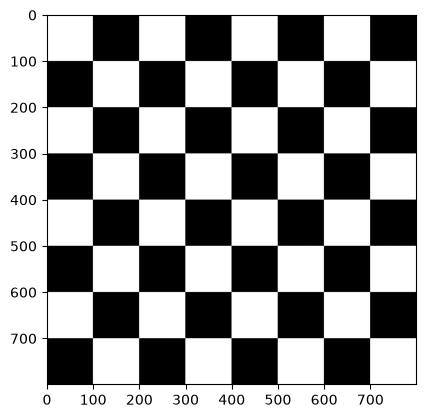

In [5]:
# Tamaño en píxeles de cada casilla del tablero de ajedrez
tam_casilla = 100

# Creamos una imagen de un único plano
# Al ser un único plano, se interpreta como nivel de gris (0 negro, 255 blanco)
gris_img = np.zeros((alto, ancho, 1), dtype = np.uint8)

# Creamos la textura del tablero de ajedrez
for i in range(0, 8):
    for j in range(0, 8):
        if (i + j) % 2 == 0:
            x = i * tam_casilla
            y = j * tam_casilla
            gris_img[y:y+tam_casilla, x:x+tam_casilla, 0] = 255

# Mostramos la imagen con matplotlib
# Al ser un plano, al visualizar, especificamos que el mapa de color usado es de grises
plt.imshow(gris_img, cmap='gray')
plt.show()

**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

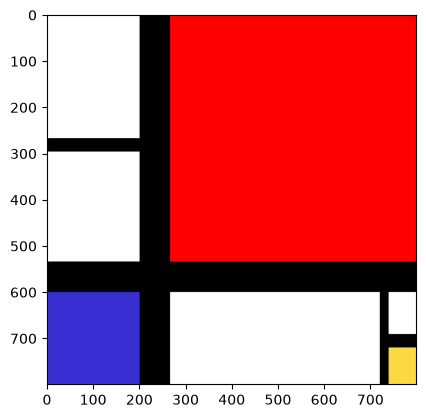

True

In [4]:
#Crea una imagen con tres planos
color_img = np.zeros((alto,ancho,3), dtype = np.uint8)

cv2.rectangle(color_img,(ancho-int(2*ancho/3),0),(ancho,int(2*alto/3)),(255, 0, 0),-1) #Rectángulo rojo
cv2.rectangle(color_img,(0,0),(int(ancho/4),int(alto/3)),(255, 255, 255),-1) #Rectángulo blanco izquierda arriba
cv2.rectangle(color_img,(0,int(alto/3)+30),(int(ancho/4),int(2*alto/3)),(255, 255, 255),-1) #Rectángulo blanco izquierda abajo
cv2.rectangle(color_img,(ancho-int(2*ancho/3),int(3*alto/4)),(ancho-80,alto),(255, 255, 255),-1) #Rectángulo blanco abajo
cv2.rectangle(color_img,(0,int(3*alto/4)),(int(ancho/4),alto),(57, 46, 209),-1) #Rectángulo azul
cv2.rectangle(color_img,(ancho-60,int(3*alto/4)),(ancho,alto-110),(255, 255, 255),-1) #Rectángulo blanco abajo derecha
cv2.rectangle(color_img,(ancho-60,alto-80),(ancho,alto),(252, 217, 66),-1) #Rectángulo amarillo

#Visualiza sin especificar el mapa de color gris
plt.imshow(color_img)
plt.show()

#Salva la imagen resultante a disco
cv2.imwrite('imagen.jpg', color_img)

**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


In [ ]:
vid = cv2.VideoCapture(0)

def search_max_and_min(image, n=None, m=None) -> tuple:
    """Devuelve las posiciones (fila, columna) del mínimo y del máximo."""
    min_position = np.unravel_index(np.argmin(image), image.shape)
    max_position = np.unravel_index(np.argmax(image), image.shape)
    return min_position, max_position

# Se define el número de celdas
ncells = 10
off = int(ncells/2)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        #Dimensiones originales
        h, w, c = frame.shape
        #Redimensiono teniendo en cuenta ncells
        down_frame = cv2.resize(frame, (int(w/ncells),int(h/ncells)),cv2.INTER_NEAREST)

        # Paso a escala de grises
        gris_down_frame = cv2.cvtColor(down_frame, cv2.COLOR_BGR2GRAY)

        # Busco el mínimo y máximo
        (mini, minj), (maxi, maxj) = search_max_and_min(gris_down_frame, int(h/ncells), int(w/ncells))

        # Rodeo las celdas de mínimo y máximo con un círculo
        cv2.circle(gris_down_frame, (minj, mini), off, (0, 0, 255), 1)
        cv2.circle(gris_down_frame, (maxj, maxi), off, (0, 255, 0), 1)

        # Muestra fotograma resultante
        cv2.imshow('Cam', gris_down_frame)
    
    # Detenemos pulsando ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

**TAREA**: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

vid = cv2.VideoCapture(0, cv2.CAP_DSHOW)

# Dimensiones de la cámara
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Fuerzo a mitad de resolución para ocupar menos pantalla
vid.set(cv2.CAP_PROP_FRAME_WIDTH, w) # En Mac no reacciona a estos comandos
vid.set(cv2.CAP_PROP_FRAME_HEIGHT, h)

# 1. Crear la malla de coordenadas (X, Y)
x = np.arange(w)
y = np.arange(h)
X, Y = np.meshgrid(x, y)

# 2. Definir las dos rectas diagonales
D1 = (h / w) * X
D2 = h - (h / w) * X

# 3. Definir las condiciones lógicas para cada uno de los 4 triángulos
condicion_arriba    = (Y < D1) & (Y < D2)
condicion_abajo     = (Y > D1) & (Y > D2)
condicion_izquierda = (Y > D1) & (Y < D2)
condicion_derecha   = (Y < D1) & (Y > D2)

# 4. Crear máscara binaria (255 para el triángulo superior, 0 para el resto)
mascara_arriba = np.zeros((h, w), dtype=np.uint8)
mascara_arriba[condicion_arriba] = 255
mascara_abajo = np.zeros((h, w), dtype=np.uint8)
mascara_abajo[condicion_abajo] = 255
mascara_izquierda = np.zeros((h, w), dtype=np.uint8)
mascara_izquierda[condicion_izquierda] = 255
mascara_derecha = np.zeros((h, w), dtype=np.uint8)
mascara_derecha[condicion_derecha] = 255

while True:
    # fotograma a fotograma
    ret, frameIN = vid.read()

    if not ret:
        break

    # 1. ESCALADOS
    # Frame principal (mitad de tamaño para los triángulos)
    sw, sh = int(w/2), int(h/2)
    frame_small = cv2.resize(frameIN, (sw, sh), interpolation=cv2.INTER_LINEAR)
    
    # Frame miniatura (cuarto de tamaño para las esquinas vacías)
    cw, ch = int(w/4), int(h/4)
    frame_mini = cv2.resize(frameIN, (cw, ch), interpolation=cv2.INTER_LINEAR)

    # 2. LIENZOS PARA LOS TRIÁNGULOS (Imágenes principales que sí se cortan)
    base_arriba = np.zeros((int(h), int(w), 3), dtype=np.uint8)
    base_abajo  = np.zeros((int(h), int(w), 3), dtype=np.uint8)
    base_izq    = np.zeros((int(h), int(w), 3), dtype=np.uint8)
    base_der    = np.zeros((int(h), int(w), 3), dtype=np.uint8)

    # Pegamos los frames principales centrados en su zona
    offset_x, offset_y = cw, ch 
    
    base_arriba[0:sh, offset_x:offset_x+sw] = frame_small
    base_abajo[sh:int(h), offset_x:offset_x+sw] = frame_small
    base_izq[offset_y:offset_y+sh, 0:sw] = frame_small
    base_der[offset_y:offset_y+sh, sw:int(w)] = frame_small

    # Cambiamos los valores de los planos
    base_abajo[:,:,0] = 255 - base_abajo[:,:,0]
    base_izq[:,:,1] = 255 - base_izq[:,:,1]
    base_der[:,:,2] = 255 - base_der[:,:,2]

    # 3. APLICAR MÁSCARAS DIAGONALES
    t_arriba    = cv2.bitwise_and(base_arriba, base_arriba, mask=mascara_arriba)
    t_abajo     = cv2.bitwise_and(base_abajo, base_abajo, mask=mascara_abajo)
    t_izquierda = cv2.bitwise_and(base_izq, base_izq, mask=mascara_izquierda)
    t_derecha   = cv2.bitwise_and(base_der, base_der, mask=mascara_derecha)

    # 4. UNIR LOS TRIÁNGULOS (El centro queda formado, las esquinas quedan en negro)
    resultado = cv2.add(cv2.add(t_arriba, t_abajo), cv2.add(t_izquierda, t_derecha))

    # 5. SUPERPONER LAS ESQUINAS SIN CORTAR
    # Sobrescribimos los pixeles negros de las 4 esquinas con los frames rectangulares
    
    # Esquina Superior Izquierda
    resultado[0:ch, 0:cw, 1] = 128 - frame_mini[:,:,1]
    
    # Esquina Superior Derecha
    resultado[0:ch, int(w)-cw:int(w), 2] = 128 - frame_mini[:,:,2]
    
    # Esquina Inferior Izquierda
    resultado[int(h)-ch:int(h), 0:cw, 0] = 255 - frame_mini[:,:,0]
    resultado[int(h)-ch:int(h), 0:cw, 1] = 255 - frame_mini[:,:,1]

    # Esquina Inferior Derecha
    resultado[int(h)-ch:int(h), int(w)-cw:int(w), 0] = 255 - frame_mini[:,:,0]
    resultado[int(h)-ch:int(h), int(w)-cw:int(w), 2] = 255 - frame_mini[:,:,2]

    # Muestra composición
    cv2.imshow('Cam', resultado)

    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

**TAREA ADICIONAL**: Desarrollar una función que permita modificar la inversión de colores que se aplica sobre la imagen mediante la rueda del ratón.